## Lab 8

In this assignment you will investigate the claim that in the case of data whrere the classes are very close (or slightly overlapping), a support vector classifier with a small value of C that misclassifies a couple of training observations may perform better on test data than one with a huge value of C that does not misclassify any training observations.

In [ ]:
# Import your libraries here
import matplotlib.pyplot as plt
import sklearn.model_selection as skm

from matplotlib.pyplot import subplots

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import make_classification
# used these references to use make_classification
# https://scikit-learn.org/stable/datasets/sample_generators.html
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html#sklearn.datasets.make_classification

from ISLP import confusion_table
from ISLP.svm import plot as plot_svm

**(a) Generate two-class data with p = 2 in such a way that the classes are slightly overlapping.**

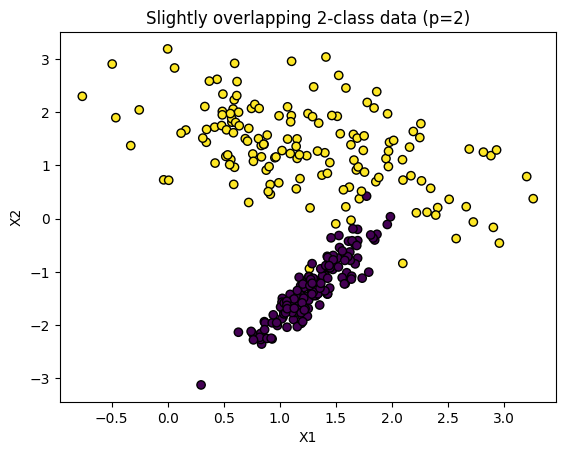

In [36]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.3,
    flip_y=0.0,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Slightly overlapping 2-class data (p=2)")
plt.show()

**(b) Compute the cross-validation error rates for support vector classifiers with a range of C values. How many training observations are misclassified for each value of C considered, and how does this relate to the cross-validation errors obtained?**

In [40]:
# train test split
X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
svm_linear = SVC(kernel='linear', random_state=42)
kfold = skm.KFold(n_splits=5, shuffle=True, random_state=42)
grid_linear = skm.GridSearchCV(
    svm_linear, 
    param_grid, 
    cv=kfold,
    scoring='accuracy',
    return_train_score=True
)

grid_linear.fit(X_train, y_train)

# cross-validation error rates
print(f'cross-validation error rates: {grid_linear.cv_results_[('mean_test_score')]}')

# misclassified training observations


cross-validation error rates: [0.52380952 0.95714286 0.96666667 0.97619048 0.97142857 0.97619048]


**(c) Generate an appropriate test data set, and compute the test errors corresponding to each of the values of C considered. Which value of C leads to the fewest test errors, and how does this compare to the values of C that yield the fewest training errors and the fewest cross-validation errors?**

**(d) Discuss your results.**